# Vietnamese Traffic Sign Detection - Notebook-first YOLO Workflow

Notebook nay la file chinh cua project. Toan bo pipeline tu **data collection -> data analysis -> data cleaning -> data preparing -> model training -> evaluation -> inference** nam trong notebook, theo style trinh bay cua file mau `Predicting_product_sales_v3.ipynb`.

## 0. Problem Definition

**Bai toan:** nhan dien bien bao giao thong Viet Nam bang YOLO object detection.

**Input:** anh, video hoac frame tu camera.

**Output:** bounding box, class bien bao, confidence score va metrics evaluation.

**Dataset mac dinh:** Kaggle `maitam/vietnamese-traffic-signs`.

**Luu y:** dataset public co the thieu mot so bien bao pho bien nhu `STOP`, va co the mat can bang class. Notebook se kiem tra, clean, remap class khong co du lieu train, va tao training dataset can bang hon.

## 1. Import Libraries

Cell nay chuan bi thu vien, cau hinh cache noi bo project, va tu cai package thieu vao dung kernel hien tai neu can.

In [ ]:
from pathlib import Path
import importlib.util
import json
import os
import random
import shutil
import subprocess
import sys
from collections import Counter
from dataclasses import dataclass

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

CACHE_ROOT = PROJECT_ROOT / ".cache"
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("YOLO_CONFIG_DIR", str(CACHE_ROOT / "ultralytics"))
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_ROOT / "matplotlib"))
os.environ.setdefault("KAGGLEHUB_CACHE", str(CACHE_ROOT / "kagglehub"))
for folder in ["ultralytics", "matplotlib", "kagglehub"]:
    (CACHE_ROOT / folder).mkdir(parents=True, exist_ok=True)

print("Python:", sys.executable)
print("Python version:", sys.version)
print("Project root:", PROJECT_ROOT)

if sys.version_info[:2] != (3, 14):
    print("WARNING: Notebook dang khong chay Python 3.14. Hay chon kernel Python 3.14 trong VS Code neu ban muon dung 3.14.")

# Windows Application Control / Smart App Control can block torch DLL/PYD files in Python 3.14 user site-packages.
# Try to remove Mark-of-the-Web streams before importing torch/ultralytics.
def unblock_torch_windows_files():
    if os.name != "nt":
        return
    candidates = []
    for site_root in [Path(p) for p in sys.path if "site-packages" in p.lower()]:
        torch_root = site_root / "torch"
        if torch_root.exists():
            candidates.append(torch_root)
    for torch_root in candidates:
        files = list(torch_root.rglob("*.dll")) + list(torch_root.rglob("*.pyd"))
        if not files:
            continue
        try:
            subprocess.run(
                ["powershell", "-NoProfile", "-ExecutionPolicy", "Bypass", "-Command", f"Get-ChildItem -LiteralPath '{torch_root}' -Recurse -Include *.dll,*.pyd | Unblock-File"],
                check=False,
                capture_output=True,
                text=True,
            )
            print(f"Checked/unblocked torch binary files in: {torch_root}")
        except Exception as exc:
            print("Could not run Unblock-File for torch binaries:", exc)

unblock_torch_windows_files()

REQUIRED_PACKAGES = {
    "cv2": "opencv-python",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "yaml": "PyYAML",
    "ultralytics": "ultralytics",
    "kagglehub": "kagglehub",
}

missing = [pip_name for module_name, pip_name in REQUIRED_PACKAGES.items() if importlib.util.find_spec(module_name) is None]
if missing:
    print("Installing missing packages into current Python 3.14 kernel:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
    unblock_torch_windows_files()

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import HTML, display

try:
    from ultralytics import YOLO
except OSError as exc:
    message = str(exc)
    if "Application Control policy" in message or "torch_global_deps.dll" in message:
        raise RuntimeError(
            "Python 3.14 dang bi Windows Application Control chan torch DLL. "
            "Notebook da thu Unblock-File nhung chua thanh cong. "
            "Hay chay PowerShell: Get-ChildItem $env:LOCALAPPDATA\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\torch -Recurse -Include *.dll,*.pyd | Unblock-File "
            "roi restart kernel, hoac cai lai torch trong moi truong Python 3.14 duoc Windows tin cay."
        ) from exc
    raise

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)


Python: c:\Users\toite\AppData\Local\Python\pythoncore-3.14-64\python.exe
Python version: 3.14.5 (tags/v3.14.5:5607950, May 10 2026, 10:43:50) [MSC v.1944 64 bit (AMD64)]
Project root: D:\UTH\AI_2026\AI_Trafic_Sign_
Checked/unblocked torch binary files in: c:\Users\toite\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch


## 1.1. Utility Helpers

Nhung helper nay thay the script `.py` ben ngoai de notebook tu chua toan bo logic xu ly.

In [ ]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def display_styled_table(df: pd.DataFrame, caption: str | None = None, max_rows: int = 20):
    view = df.head(max_rows).copy()
    styler = view.style.set_table_styles([
        {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "16px"), ("font-weight", "bold")]},
        {"selector": "th", "props": [("background", "#1f2937"), ("color", "white")]},
    ])
    if caption:
        styler = styler.set_caption(caption)
    display(styler)

def write_yaml(path: Path, data: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(yaml.safe_dump(data, sort_keys=False, allow_unicode=True), encoding="utf-8")

def read_yaml(path: Path) -> dict:
    return yaml.safe_load(path.read_text(encoding="utf-8")) or {}

def normalize_names(names) -> dict[int, str]:
    if isinstance(names, list):
        return {i: str(name) for i, name in enumerate(names)}
    return {int(k): str(v) for k, v in names.items()}

def link_or_copy(source: Path, destination: Path, use_copy: bool = False):
    destination.parent.mkdir(parents=True, exist_ok=True)
    if destination.exists():
        destination.unlink()
    if use_copy:
        shutil.copy2(source, destination)
        return
    try:
        destination.hardlink_to(source)
    except OSError:
        shutil.copy2(source, destination)

def label_path_for_image(image_path: Path, images_dir: Path) -> Path:
    relative = image_path.relative_to(images_dir)
    return images_dir.parent.parent / "labels" / images_dir.name / relative.with_suffix(".txt")

def read_yolo_label(label_path: Path) -> list[dict]:
    rows = []
    if not label_path.exists():
        return rows
    for line_no, raw_line in enumerate(label_path.read_text(encoding="utf-8").splitlines(), 1):
        line = raw_line.strip()
        if not line:
            continue
        parts = line.split()
        if len(parts) != 5:
            rows.append({"error": f"invalid format at line {line_no}: {line}"})
            continue
        try:
            class_id = int(parts[0])
            x_center, y_center, width, height = map(float, parts[1:])
            rows.append({
                "class_id": class_id,
                "x_center": x_center,
                "y_center": y_center,
                "width": width,
                "height": height,
                "area": width * height,
            })
        except ValueError:
            rows.append({"error": f"non numeric label at line {line_no}: {line}"})
    return rows

def resolve_split_dir(data_yaml: Path, split: str) -> Path:
    cfg = read_yaml(data_yaml)
    root = Path(cfg.get("path", data_yaml.parent))
    if not root.is_absolute():
        root = (data_yaml.parent / root).resolve()
    split_path = Path(cfg[split])
    return split_path if split_path.is_absolute() else root / split_path

## 1.2. End-to-End Processing Flow

In [ ]:
display(HTML("""
<div style="font-family:Arial; max-width:900px;">
  <div style="padding:12px; background:#e8f1ff; border:1px solid #9db7df; border-radius:10px; text-align:center;"><b>Data Collection</b></div>
  <div style="text-align:center; font-size:24px;">&#8595;</div>
  <div style="padding:12px; background:#e9f8ef; border:1px solid #96c5a4; border-radius:10px; text-align:center;"><b>Exploring Data Analysis</b></div>
  <div style="text-align:center; font-size:24px;">&#8595;</div>
  <div style="padding:12px; background:#f2efff; border:1px solid #aea6db; border-radius:10px; text-align:center;"><b>Data Cleaning</b></div>
  <div style="text-align:center; font-size:24px;">&#8595;</div>
  <div style="padding:12px; background:#fff5df; border:1px solid #d6bc7b; border-radius:10px; text-align:center;"><b>Data Preparing</b></div>
  <div style="text-align:center; font-size:24px;">&#8595;</div>
  <div style="padding:12px; background:#fdecea; border:1px solid #d9aaa2; border-radius:10px; text-align:center;"><b>Model Training</b></div>
  <div style="text-align:center; font-size:24px;">&#8595;</div>
  <div style="padding:12px; background:#edf7e7; border:1px solid #a8c991; border-radius:10px; text-align:center;"><b>Evaluation</b></div>
  <div style="text-align:center; font-size:24px;">&#8595;</div>
  <div style="padding:12px; background:#fce7f3; border:1px solid #d59ab8; border-radius:10px; text-align:center;"><b>Inference</b></div>
</div>
"""))

## **`2. Data Collection`**

Tai dataset Kaggle va chuan hoa sang YOLO structure.

In [ ]:
KAGGLE_DATASET = "maitam/vietnamese-traffic-signs"
DATA_ROOT = PROJECT_ROOT / "data"
PREPARED_ROOT = DATA_ROOT / "processed" / "vietnamese-traffic-signs-kaggle"
DATA_YAML = DATA_ROOT / "data.yaml"

def find_kaggle_archive() -> Path | None:
    candidates = sorted((CACHE_ROOT / "kagglehub" / "datasets" / "maitam" / "vietnamese-traffic-signs" / "versions").glob("*/archive"))
    valid = [path for path in candidates if (path / "images").exists() and (path / "labels").exists()]
    return valid[-1] if valid else None

KAGGLE_ARCHIVE = find_kaggle_archive()
if KAGGLE_ARCHIVE is None:
    import kagglehub
    downloaded_path = Path(kagglehub.dataset_download(KAGGLE_DATASET))
    KAGGLE_ARCHIVE = downloaded_path if (downloaded_path / "images").exists() else find_kaggle_archive()

if KAGGLE_ARCHIVE is None or not KAGGLE_ARCHIVE.exists():
    raise FileNotFoundError("Could not locate Kaggle dataset archive after download.")

print("Kaggle archive:", KAGGLE_ARCHIVE)

Kaggle archive: D:\UTH\AI_2026\AI_Trafic_Sign_\.cache\kagglehub\datasets\maitam\vietnamese-traffic-signs\versions\8\archive


### **2.1. Convert Kaggle Dataset to YOLO Split**

In [ ]:
def read_lines(path: Path) -> list[str]:
    return [line.strip() for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]

def prepare_split(source_root: Path, output_root: Path, split: str, filenames: list[str]) -> int:
    written = 0
    for filename in filenames:
        image_source = source_root / "images" / filename
        if not image_source.exists():
            candidates = [source_root / "images" / Path(filename).with_suffix(ext) for ext in IMAGE_EXTENSIONS]
            candidates = [path for path in candidates if path.exists()]
            if not candidates:
                raise FileNotFoundError(f"Missing image: {filename}")
            image_source = candidates[0]
        label_source = source_root / "labels" / image_source.with_suffix(".txt").name
        if not label_source.exists():
            raise FileNotFoundError(f"Missing label: {label_source}")
        link_or_copy(image_source, output_root / "images" / split / image_source.name)
        link_or_copy(label_source, output_root / "labels" / split / label_source.name)
        written += 1
    return written

if True:
    required = [
        KAGGLE_ARCHIVE / "images",
        KAGGLE_ARCHIVE / "labels",
        KAGGLE_ARCHIVE / "split_dataset" / "train_files.txt",
        KAGGLE_ARCHIVE / "split_dataset" / "test_files.txt",
        KAGGLE_ARCHIVE / "classes_en.txt",
    ]
    missing = [path for path in required if not path.exists()]
    if missing:
        raise FileNotFoundError("Missing dataset files: " + ", ".join(str(x) for x in missing))
    train_candidates = read_lines(KAGGLE_ARCHIVE / "split_dataset" / "train_files.txt")
    test_files = sorted(read_lines(KAGGLE_ARCHIVE / "split_dataset" / "test_files.txt"))
    rng = random.Random(42)
    rng.shuffle(train_candidates)
    val_count = max(1, int(len(train_candidates) * 0.15))
    val_files = sorted(train_candidates[:val_count])
    train_files = sorted(train_candidates[val_count:])
    counts = {
        "train": prepare_split(KAGGLE_ARCHIVE, PREPARED_ROOT, "train", train_files),
        "val": prepare_split(KAGGLE_ARCHIVE, PREPARED_ROOT, "val", val_files),
        "test": prepare_split(KAGGLE_ARCHIVE, PREPARED_ROOT, "test", test_files),
    }
    class_names = read_lines(KAGGLE_ARCHIVE / "classes_en.txt")
    write_yaml(DATA_YAML, {
        "path": str(PREPARED_ROOT).replace("\\", "/"),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "names": {i: name for i, name in enumerate(class_names)},
    })
else:
    counts = {"status": "already prepared"}

counts

{'train': 2170, 'val': 382, 'test': 639}

## **`3. Exploratory Data Analysis (EDA)`**

In [ ]:
cfg = read_yaml(DATA_YAML)
names = normalize_names(cfg["names"])
dataset_root = Path(cfg["path"])
if not dataset_root.is_absolute():
    dataset_root = (DATA_YAML.parent / dataset_root).resolve()

display_styled_table(pd.DataFrame({"class_id": list(names.keys()), "class_name": list(names.values())}), "Class Map", 60)
print("Dataset root:", dataset_root)
print("Classes:", len(names))

,class_id,class_name
0,0,Pedestrian Crossing
1,1,Equal-level Intersection
2,2,No Entry
3,3,Right Turn Only
4,4,Intersection
5,5,Intersection with a non-priority road
6,6,Danger zone on the left
7,7,No Left Turn
8,8,Bus Stop
9,9,Roundabout


Dataset root: D:\UTH\AI_2026\AI_Trafic_Sign_\data\processed\vietnamese-traffic-signs-kaggle
Classes: 52


In [ ]:
def scan_yolo_dataset(data_yaml: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    cfg = read_yaml(data_yaml)
    names_local = normalize_names(cfg["names"])
    image_records, label_records = [], []
    for split in ["train", "val", "test"]:
        images_dir = resolve_split_dir(data_yaml, split)
        image_paths = sorted(path for path in images_dir.rglob("*") if path.suffix.lower() in IMAGE_EXTENSIONS)
        for image_path in image_paths:
            label_path = label_path_for_image(image_path, images_dir)
            labels = read_yolo_label(label_path)
            valid_labels = [label for label in labels if "error" not in label]
            image_records.append({
                "split": split,
                "image_path": image_path,
                "label_path": label_path,
                "has_label_file": label_path.exists(),
                "objects": len(valid_labels),
            })
            for label in labels:
                class_id = label.get("class_id")
                label_records.append({
                    "split": split,
                    "image_path": image_path,
                    "label_path": label_path,
                    "class_name": names_local.get(class_id, f"unknown_{class_id}"),
                    **label,
                })
    return pd.DataFrame(image_records), pd.DataFrame(label_records)

images_df, labels_df = scan_yolo_dataset(DATA_YAML)
summary_df = images_df.groupby("split").agg(images=("image_path", "count"), objects=("objects", "sum"), avg_objects=("objects", "mean")).reset_index()
display_styled_table(summary_df, "Split Summary")

,split,images,objects,avg_objects
0,test,639,1645,2.574335
1,train,2170,5683,2.618894
2,val,382,1006,2.633508


,class_id,class_name,objects
10,10,No Stopping and No Parking,1071
2,2,No Entry,470
23,23,No Two or Three-wheeled Vehicles,465
39,39,Speed limit (60km/h),459
3,3,Right Turn Only,454
46,46,No Parking,435
13,13,Slow Down,372
0,0,Pedestrian Crossing,312
12,12,Lane Allocation,280
41,41,Speed limit (40km/h),275


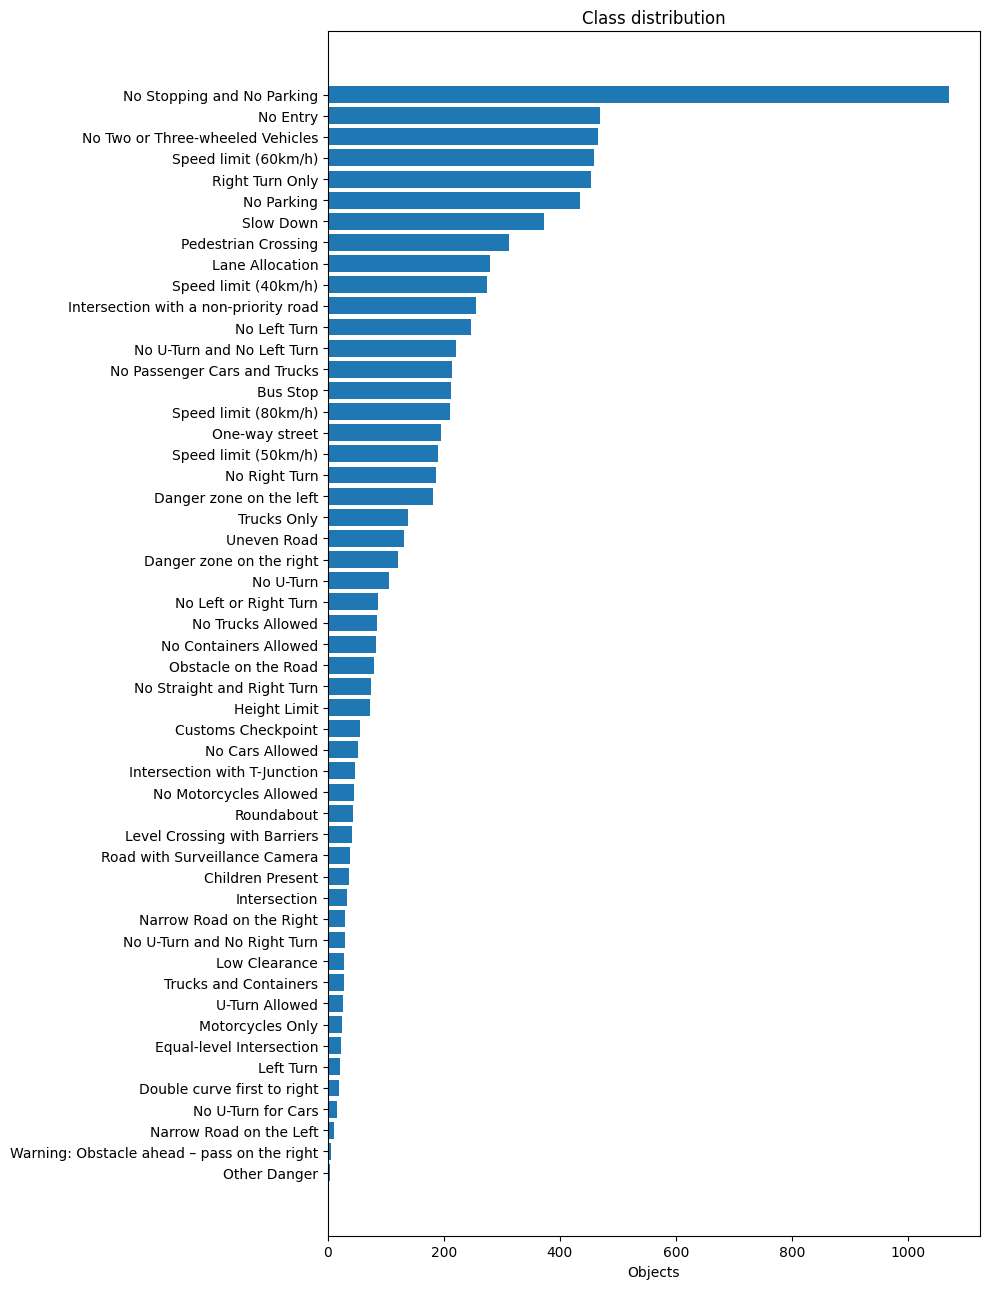

In [ ]:
valid_labels_df = labels_df[labels_df.get("error").isna()] if "error" in labels_df.columns else labels_df.copy()
class_counts = valid_labels_df.groupby(["class_id", "class_name"]).size().reset_index(name="objects").sort_values("objects", ascending=False)
display_styled_table(class_counts, "Class Distribution", 60)

plt.figure(figsize=(10, max(8, len(class_counts) * 0.25)))
plot_df = class_counts.sort_values("objects")
plt.barh(plot_df["class_name"], plot_df["objects"])
plt.title("Class distribution")
plt.xlabel("Objects")
plt.tight_layout()
plt.show()

## **`4. DATA CLEANING`**

Loai bo anh loi, label loi, bbox khong hop le, duplicate file, sau do loai/remap class khong co du lieu train. Buoc remap nay quan trong: YOLO khong nen duoc khai bao 52 class neu mot so class khong co mau train.

In [ ]:
cfg = read_yaml(DATA_YAML)
names = normalize_names(cfg["names"])

BASIC_CLEAN_ROOT = DATA_ROOT / "processed" / "vietnamese-traffic-signs-kaggle-basic-clean"
CLEAN_ROOT = DATA_ROOT / "processed" / "vietnamese-traffic-signs-kaggle-clean"
CLEAN_YAML = DATA_ROOT / "data.clean.yaml"
MIN_BBOX_AREA = 0.00005

def validate_label_file(label_path: Path, class_count: int):
    valid_lines, reasons = [], []
    if not label_path.exists():
        return valid_lines, ["missing_label"]
    for line_no, raw_line in enumerate(label_path.read_text(encoding="utf-8").splitlines(), 1):
        line = raw_line.strip()
        if not line:
            continue
        parts = line.split()
        if len(parts) != 5:
            reasons.append(f"invalid_format:{line_no}")
            continue
        try:
            class_id = int(parts[0])
            x, y, w, h = map(float, parts[1:])
        except ValueError:
            reasons.append(f"non_numeric:{line_no}")
            continue
        if class_id < 0 or class_id >= len(names):
            reasons.append(f"class_out_of_range:{line_no}")
            continue
        if any(v < 0 or v > 1 for v in [x, y, w, h]):
            reasons.append(f"bbox_outside_0_1:{line_no}")
            continue
        if w <= 0 or h <= 0 or w * h < MIN_BBOX_AREA:
            reasons.append(f"bbox_invalid_or_too_small:{line_no}")
            continue
        valid_lines.append(f"{class_id} {x:.8f} {y:.8f} {w:.8f} {h:.8f}")
    if not valid_lines:
        reasons.append("empty_or_no_valid_labels")
    return valid_lines, reasons

def sha256_file(path: Path):
    import hashlib
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def reset_yolo_dirs(root: Path):
    for split in ["train", "val", "test"]:
        for folder in [root / "images" / split, root / "labels" / split]:
            if folder.exists():
                shutil.rmtree(folder)
            folder.mkdir(parents=True, exist_ok=True)

reset_yolo_dirs(BASIC_CLEAN_ROOT)

seen_hashes = set()
clean_report = {"summary": {}, "rejected": []}
for split in ["train", "val", "test"]:
    images_dir = resolve_split_dir(DATA_YAML, split)
    image_paths = sorted(path for path in images_dir.rglob("*") if path.suffix.lower() in IMAGE_EXTENSIONS)
    kept = 0
    reasons_counter = Counter()
    for image_path in image_paths:
        label_path = label_path_for_image(image_path, images_dir)
        reasons = []
        image = cv2.imread(str(image_path))
        if image is None:
            reasons.append("unreadable_image")
        valid_lines, label_reasons = validate_label_file(label_path, len(names))
        reasons.extend(label_reasons)
        image_hash = None
        if image is not None:
            image_hash = sha256_file(image_path)
            if image_hash in seen_hashes:
                reasons.append("duplicate_file")
        if reasons:
            reasons_counter.update(reasons)
            clean_report["rejected"].append({"split": split, "image": str(image_path), "reason": ";".join(reasons)})
            continue
        link_or_copy(image_path, BASIC_CLEAN_ROOT / "images" / split / image_path.name)
        out_label = BASIC_CLEAN_ROOT / "labels" / split / label_path.name
        out_label.write_text("\n".join(valid_lines) + "\n", encoding="utf-8")
        seen_hashes.add(image_hash)
        kept += 1
    clean_report["summary"][split] = {"total": len(image_paths), "kept": kept, "removed": len(image_paths) - kept, "reasons": dict(reasons_counter)}

basic_cfg = dict(cfg)
basic_cfg["path"] = str(BASIC_CLEAN_ROOT).replace("\\", "/")
basic_cfg["train"] = "images/train"
basic_cfg["val"] = "images/val"
basic_cfg["test"] = "images/test"
BASIC_CLEAN_YAML = DATA_ROOT / "data.basic-clean.yaml"
write_yaml(BASIC_CLEAN_YAML, basic_cfg)

# Keep only classes that actually have training data, then remap ids to 0..N-1.
basic_images_df, basic_labels_df = scan_yolo_dataset(BASIC_CLEAN_YAML)
valid_basic_labels = basic_labels_df[basic_labels_df.get("error").isna()] if "error" in basic_labels_df.columns else basic_labels_df
train_active_ids = sorted(valid_basic_labels.loc[valid_basic_labels["split"] == "train", "class_id"].dropna().astype(int).unique().tolist())
if not train_active_ids:
    raise ValueError("No active train classes found after cleaning.")

old_to_new = {old_id: new_id for new_id, old_id in enumerate(train_active_ids)}
new_names = {new_id: names[old_id] for old_id, new_id in old_to_new.items()}
removed_classes = [{"old_class_id": old_id, "class_name": names[old_id]} for old_id in names if old_id not in old_to_new]

reset_yolo_dirs(CLEAN_ROOT)
remap_report = {"kept_images": {}, "removed_images": {}, "removed_classes": removed_classes}
for split in ["train", "val", "test"]:
    kept = 0
    removed = 0
    images_dir = BASIC_CLEAN_ROOT / "images" / split
    for image_path in sorted(path for path in images_dir.rglob("*") if path.suffix.lower() in IMAGE_EXTENSIONS):
        label_path = label_path_for_image(image_path, images_dir)
        new_lines = []
        for label in read_yolo_label(label_path):
            if "error" in label:
                continue
            old_id = int(label["class_id"])
            if old_id not in old_to_new:
                continue
            new_lines.append(f"{old_to_new[old_id]} {label['x_center']:.8f} {label['y_center']:.8f} {label['width']:.8f} {label['height']:.8f}")
        if not new_lines:
            removed += 1
            continue
        link_or_copy(image_path, CLEAN_ROOT / "images" / split / image_path.name)
        (CLEAN_ROOT / "labels" / split / label_path.name).write_text("\n".join(new_lines) + "\n", encoding="utf-8")
        kept += 1
    remap_report["kept_images"][split] = kept
    remap_report["removed_images"][split] = removed

clean_cfg = {
    "path": str(CLEAN_ROOT).replace("\\", "/"),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": new_names,
}
write_yaml(CLEAN_YAML, clean_cfg)
(CLEAN_ROOT / "filter_report.json").write_text(json.dumps(clean_report, indent=2, ensure_ascii=False), encoding="utf-8")
(CLEAN_ROOT / "remap_report.json").write_text(json.dumps(remap_report, indent=2, ensure_ascii=False), encoding="utf-8")

cfg = read_yaml(CLEAN_YAML)
names = normalize_names(cfg["names"])
display_styled_table(pd.DataFrame([{"split": k, **v} for k, v in clean_report["summary"].items()]), "Cleaning Summary")
display_styled_table(pd.DataFrame(remap_report["removed_classes"]), "Removed Classes Without Train Data", 80)
print("Active train classes after remap:", len(names))
print("Clean dataset:", CLEAN_YAML)

,split,total,kept,removed,reasons
0,train,2170,2170,0,{}
1,val,382,382,0,{}
2,test,639,639,0,{}


Active train classes after remap: 52
Clean dataset: D:\UTH\AI_2026\AI_Trafic_Sign_\data\data.clean.yaml


## **`5. DATA PREPARING`**

Section nay tao dataset train that cho YOLO. Train split duoc can bang hon bang cach cap class qua nhieu va oversample class qua it. Val/test giu theo clean data sau remap de evaluation trung thuc.

In [ ]:
SOURCE_DATA_YAML = CLEAN_YAML
TRAINING_ROOT = DATA_ROOT / "processed" / "vietnamese-traffic-signs-kaggle-training-balanced"
TRAINING_YAML = DATA_ROOT / "data.training.yaml"
RUNTIME_DATA_YAML = CACHE_ROOT / "data.training.runtime.yaml"

MIN_TRAIN_OBJECTS_PER_CLASS = 40
MAX_TRAIN_OBJECTS_PER_CLASS = 180
MIN_TEST_OBJECTS_FOR_REPORT = 5

source_cfg = read_yaml(SOURCE_DATA_YAML)
names = normalize_names(source_cfg["names"])

reset_yolo_dirs(TRAINING_ROOT)

source_train_dir = resolve_split_dir(SOURCE_DATA_YAML, "train")
samples = []
original_train_counts = Counter()
for image_path in sorted(path for path in source_train_dir.rglob("*") if path.suffix.lower() in IMAGE_EXTENSIONS):
    label_path = label_path_for_image(image_path, source_train_dir)
    class_counts = Counter()
    for label in read_yolo_label(label_path):
        if "error" not in label:
            class_counts[int(label["class_id"])] += 1
    if class_counts:
        samples.append({"image_path": image_path, "label_path": label_path, "class_counts": class_counts})
        original_train_counts.update(class_counts)

if not samples:
    raise ValueError("No train samples found after cleaning/remap.")

rng = random.Random(42)
rng.shuffle(samples)
samples.sort(key=lambda sample: min(original_train_counts[cid] for cid in sample["class_counts"]))

selected = []
selected_counts = Counter()
for sample in samples:
    would_exceed = any(
        selected_counts[cid] + count > MAX_TRAIN_OBJECTS_PER_CLASS
        for cid, count in sample["class_counts"].items()
    )
    if not would_exceed:
        selected.append((sample, ""))
        selected_counts.update(sample["class_counts"])

# Guarantee at least one image for every class that exists in the source train split.
selected_paths = {sample["image_path"] for sample, _ in selected}
for cid in names:
    if original_train_counts[cid] > 0 and selected_counts[cid] == 0:
        candidates = [sample for sample in samples if cid in sample["class_counts"]]
        chosen = min(candidates, key=lambda sample: sum(selected_counts[k] for k in sample["class_counts"]))
        selected.append((chosen, ""))
        selected_paths.add(chosen["image_path"])
        selected_counts.update(chosen["class_counts"])

# Oversample rare classes. This duplicates real training images only when the dataset is genuinely too small.
duplicate_index = 0
for cid in names:
    candidates = [sample for sample in samples if cid in sample["class_counts"]]
    if not candidates:
        continue
    candidate_index = 0
    candidates = sorted(candidates, key=lambda sample: sum(original_train_counts[k] for k in sample["class_counts"]))
    while selected_counts[cid] < MIN_TRAIN_OBJECTS_PER_CLASS:
        sample = candidates[candidate_index % len(candidates)]
        duplicate_index += 1
        selected.append((sample, f"__dup{duplicate_index:05d}"))
        selected_counts.update(sample["class_counts"])
        candidate_index += 1

# Prune samples that mostly keep over-represented classes high, while preserving the minimum target for every class.
changed = True
while changed:
    changed = False
    removable_order = sorted(
        range(len(selected)),
        key=lambda idx: (0 if selected[idx][1] else 1, -sum(selected_counts[c] for c in selected[idx][0]["class_counts"])),
    )
    for idx in removable_order:
        sample, suffix = selected[idx]
        class_counts = sample["class_counts"]
        helps_over_cap = any(selected_counts[cid] > MAX_TRAIN_OBJECTS_PER_CLASS for cid in class_counts)
        keeps_minimums = all(selected_counts[cid] - count >= MIN_TRAIN_OBJECTS_PER_CLASS for cid, count in class_counts.items())
        if helps_over_cap and keeps_minimums:
            selected_counts.subtract(class_counts)
            del selected[idx]
            changed = True
            break

for output_index, (sample, suffix) in enumerate(selected):
    image_path = sample["image_path"]
    label_path = sample["label_path"]
    if not suffix:
        out_name = image_path.name
        out_label_name = label_path.name
    else:
        out_name = f"{image_path.stem}{suffix}{image_path.suffix}"
        out_label_name = f"{image_path.stem}{suffix}.txt"
    link_or_copy(image_path, TRAINING_ROOT / "images" / "train" / out_name)
    link_or_copy(label_path, TRAINING_ROOT / "labels" / "train" / out_label_name, use_copy=True)

for split in ["val", "test"]:
    source_dir = resolve_split_dir(SOURCE_DATA_YAML, split)
    for image_path in sorted(path for path in source_dir.rglob("*") if path.suffix.lower() in IMAGE_EXTENSIONS):
        label_path = label_path_for_image(image_path, source_dir)
        link_or_copy(image_path, TRAINING_ROOT / "images" / split / image_path.name)
        link_or_copy(label_path, TRAINING_ROOT / "labels" / split / label_path.name, use_copy=True)

training_cfg = {
    "path": str(TRAINING_ROOT).replace("\\", "/"),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": names,
}
write_yaml(TRAINING_YAML, training_cfg)

runtime_cfg = read_yaml(TRAINING_YAML)
runtime_root = Path(runtime_cfg.get("path", TRAINING_YAML.parent))
if not runtime_root.is_absolute():
    runtime_root = (TRAINING_YAML.parent / runtime_root).resolve()
runtime_cfg["path"] = str(runtime_root).replace("\\", "/")
write_yaml(RUNTIME_DATA_YAML, runtime_cfg)

images_df, labels_df = scan_yolo_dataset(TRAINING_YAML)
if images_df.empty:
    raise ValueError("No images found after preparing training dataset.")

summary_df = images_df.groupby("split").agg(images=("image_path", "count"), objects=("objects", "sum")).reset_index()
display_styled_table(summary_df, "Prepared YOLO Dataset")

balanced_train_counts = labels_df[labels_df["split"] == "train"].groupby("class_id").size().to_dict()
balance_rows = []
for class_id, class_name in names.items():
    balance_rows.append({
        "class_id": int(class_id),
        "class_name": class_name,
        "original_train_objects": int(original_train_counts.get(class_id, 0)),
        "balanced_train_objects": int(balanced_train_counts.get(class_id, 0)),
        "below_min_target": int(balanced_train_counts.get(class_id, 0)) < MIN_TRAIN_OBJECTS_PER_CLASS,
        "above_max_target": int(balanced_train_counts.get(class_id, 0)) > MAX_TRAIN_OBJECTS_PER_CLASS,
    })
display_styled_table(pd.DataFrame(balance_rows).sort_values("balanced_train_objects"), "Train Object Balancing Report", 120)
print("Runtime data:", RUNTIME_DATA_YAML)

full_class_rows = []
for split in ["train", "val", "test"]:
    split_labels = labels_df[labels_df["split"] == split]
    class_counts = split_labels.groupby("class_id").size().to_dict() if not split_labels.empty else {}
    for class_id, class_name in names.items():
        full_class_rows.append({
            "split": split,
            "class_id": int(class_id),
            "class_name": class_name,
            "objects": int(class_counts.get(int(class_id), 0)),
        })

full_class_df = pd.DataFrame(full_class_rows)
display_styled_table(full_class_df.sort_values(["split", "objects"], ascending=[True, True]), "Object Count by Class", 120)

test_support_df = full_class_df[full_class_df["split"] == "test"].copy()
test_support_df["enough_for_evaluation"] = test_support_df["objects"] >= MIN_TEST_OBJECTS_FOR_REPORT
display_styled_table(
    test_support_df.sort_values(["enough_for_evaluation", "objects"], ascending=[True, True]),
    "Evaluation Support by Class",
    120,
)

,split,images,objects
0,test,639,1645
1,train,1701,4368
2,val,382,1006


,class_id,class_name,original_train_objects,balanced_train_objects,below_min_target,above_max_target
1,1,Equal-level Intersection,13,40,False,False
4,4,Intersection,22,40,False,False
11,11,U-Turn Allowed,17,40,False,False
9,9,Roundabout,29,40,False,False
15,15,Narrow Road on the Right,15,40,False,False
29,29,No Motorcycles Allowed,30,40,False,False
20,20,No Cars Allowed,37,40,False,False
31,31,Road with Surveillance Camera,26,40,False,False
24,24,Customs Checkpoint,36,40,False,False
25,25,Motorcycles Only,18,40,False,False


Runtime data: D:\UTH\AI_2026\AI_Trafic_Sign_\.cache\data.training.runtime.yaml


,split,class_id,class_name,objects
148,test,44,Other Danger,1
155,test,51,Warning: Obstacle ahead – pass on the right,1
125,test,21,Narrow Road on the Left,3
129,test,25,Motorcycles Only,4
146,test,42,Left Turn,4
105,test,1,Equal-level Intersection,5
137,test,33,Double curve first to right,5
141,test,37,Intersection with T-Junction,5
151,test,47,No U-Turn for Cars,5
133,test,29,No Motorcycles Allowed,6


,split,class_id,class_name,objects,enough_for_evaluation
148,test,44,Other Danger,1,False
155,test,51,Warning: Obstacle ahead – pass on the right,1,False
125,test,21,Narrow Road on the Left,3,False
129,test,25,Motorcycles Only,4,False
146,test,42,Left Turn,4,False
105,test,1,Equal-level Intersection,5,True
137,test,33,Double curve first to right,5,True
141,test,37,Intersection with T-Junction,5,True
151,test,47,No U-Turn for Cars,5,True
133,test,29,No Motorcycles Allowed,6,True


## **`6. MODEL TRAINING & VALIDATION`**

In [ ]:
BASE_MODEL = "yolo11n.pt"
FALLBACK_MODEL = "yolo11n.yaml"  # fallback neu Python 3.14 / torch khong load duoc checkpoint .pt
EPOCHS = 10
IMGSZ = 416
BATCH = 8
WORKERS = 2
PATIENCE = 5
RUN_NAME = "vietnam-traffic-sign-yolo-balanced"
PROJECT_DIR = PROJECT_ROOT / "runs" / "train"

try:
    import torch
    import torch._utils as torch_utils
    if not hasattr(torch, "_utils"):
        torch._utils = torch_utils
    print("Torch:", torch.__version__)
except Exception as exc:
    print("Torch compatibility precheck warning:", exc)

print("Training config")
print("data:", RUNTIME_DATA_YAML)
print("model:", BASE_MODEL)
print("epochs:", EPOCHS)
print("imgsz:", IMGSZ)
print("batch:", BATCH)

try:
    model = YOLO(BASE_MODEL)
    model_used = BASE_MODEL
except AttributeError as exc:
    if "_utils" not in str(exc):
        raise
    print("Cannot load pretrained .pt on this Python/Torch setup. Falling back to YAML architecture.")
    model = YOLO(FALLBACK_MODEL)
    model_used = FALLBACK_MODEL

train_results = model.train(
    data=str(RUNTIME_DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    workers=WORKERS,
    device=0,
    cache=True,
    project=str(PROJECT_DIR),
    name=RUN_NAME,
    seed=42,
    patience=PATIENCE,
    exist_ok=True,
    plots=True,
)

BEST_WEIGHT = PROJECT_DIR / RUN_NAME / "weights" / "best.pt"
print("Model used:", model_used)
print("Best weight:", BEST_WEIGHT)

Torch: 2.12.1+cpu
Training config
data: D:\UTH\AI_2026\AI_Trafic_Sign_\.cache\data.training.runtime.yaml
model: yolo11n.pt
epochs: 50
imgsz: 640
batch: 8
New https://pypi.org/project/ultralytics/8.4.83 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.81  Python-3.14.5 torch-2.12.1+cpu CPU (Intel Core Ultra 5 125H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\UTH\AI_2026\AI_Trafic_Sign_\.cache\data.training.runtime.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, 

KeyboardInterrupt: 

## **`7. MODEL EVALUATION`**

In [ ]:
if not BEST_WEIGHT.exists():
    raise FileNotFoundError(f"Missing weight: {BEST_WEIGHT}")

eval_model = YOLO(str(BEST_WEIGHT))
metrics = eval_model.val(
    data=str(RUNTIME_DATA_YAML),
    split="test",
    imgsz=IMGSZ,
    project=str(PROJECT_ROOT / "runs" / "eval"),
    name=f"{RUN_NAME}-test",
    plots=True,
)

evaluation_df = pd.DataFrame([{
    "run_name": RUN_NAME,
    "mAP50": float(metrics.box.map50),
    "mAP50_95": float(metrics.box.map),
    "precision": float(metrics.box.mp),
    "recall": float(metrics.box.mr),
    "best_weight": str(BEST_WEIGHT),
}])
display_styled_table(evaluation_df, "Evaluation Metrics")

## **`8. INFERENCE`**

In [ ]:
CONF_THRES = 0.25
sample_pool = images_df[(images_df["split"] == "test") & (images_df["objects"] > 0)]
if sample_pool.empty:
    raise ValueError("No labeled test image available for inference sample.")

sample = sample_pool.sample(n=1, random_state=15).iloc[0]
result = eval_model.predict(source=str(sample["image_path"]), conf=CONF_THRES, imgsz=IMGSZ, verbose=False)[0]
annotated = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
plt.imshow(annotated)
plt.axis("off")
plt.title(f"Inference sample: {sample['image_path'].name}")
plt.show()

if result.boxes is not None and len(result.boxes) > 0:
    rows = []
    for class_id, conf in zip(result.boxes.cls.tolist(), result.boxes.conf.tolist()):
        class_id = int(class_id)
        rows.append({"class_id": class_id, "class_name": result.names[class_id], "confidence": float(conf)})
    display_styled_table(pd.DataFrame(rows).sort_values("confidence", ascending=False), "Predictions")
else:
    print("No detection on this sample. Try lower CONF_THRES, another image, or more training.")

camera_command = f'yolo predict model="{BEST_WEIGHT}" source=0 show=True conf={CONF_THRES} imgsz={IMGSZ}'
print("Camera command - run in terminal after training:")
print(camera_command)

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
from ultralytics import YOLO
from IPython.display import Image, display
from pathlib import Path

model = YOLO("/content/runs/train/vietnam-traffic-sign-yolo-balanced/weights/best.pt")

for img_path in uploaded.keys():
    results = model.predict(
        source=img_path,
        conf=0.25,
        imgsz=416,
        device=0,
        save=True
    )

latest = sorted(Path("/content/runs/detect").glob("predict*"))[-1]
for img in latest.glob("*"):
    display(Image(filename=str(img)))